In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV, train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin, ClassifierMixin
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from metric_learn import MLKR, LMNN
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# access the training sets
from dataset import training_set_1, training_set_2, training_set_3

# access the binning function
from redshift_fn import binDataFunc, randomsplit, plot_classification, plot_classification_scatter

# access required function
from redshift_fn import eta_015

# AdaBoost 1

Training sources: 918
Testing sources: 393
Number of classes: 15
Training classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Testing classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Fitting 10 folds for each of 60 candidates, totalling 600 fits

GridSearchCV Results
Best CV accuracy: 0.34628523650262777
Best parameters: {'estimator__max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 100}
AdaBoost-1 Final Results
Training : Random 70% ATLAS
Testing  : Random 30% ATLAS

Best AdaBoost parameters:
Number of estimators: 100
Learning rate: 0.1
Tree depth: 3

10-fold CV accuracy: 0.34628523650262777

Photometric-redshift metrics:
eta_0.15  : 10.178117048346055 %
eta_2sigma: 5.089058524173027 %
Test classification accuracy: 0.33078880407124683
sigma     : 0.1378364
sigma_NMAD: 0.063005835
MAE       : 0.1300025
RMSE      : 0.30315343
R²        : 0.4575274586677551


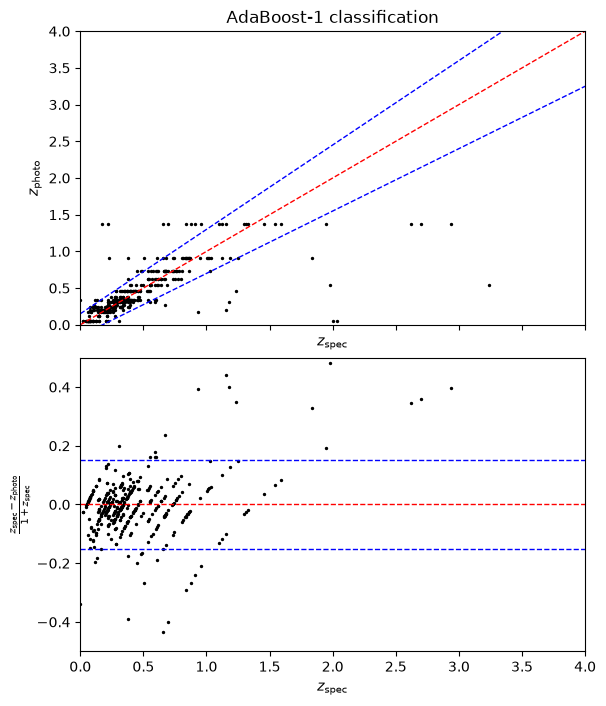

In [11]:
# Load data
file_path = "/home/sk/Projects/Astrophysics/data/ATLAS.csv"
X_train, X_test, y_train, y_test = training_set_1(file_path)

# Combine redshifts and create 15 bins
y_all = np.concatenate([y_train, y_test])
y_all_binned, bin_edges, bin_values = binDataFunc(y_all.copy(), 15)

# Separate binned redshifts
n_train = len(y_train)
y_train_binned = y_all_binned[:n_train]
y_test_binned = y_all_binned[n_train:]

print("Training sources:", len(X_train))
print("Testing sources:", len(X_test))

# Convert binned redshifts to integer class labels
y_train_class = np.searchsorted(bin_values, y_train_binned).astype(int)
y_test_class = np.searchsorted(bin_values, y_test_binned).astype(int)

print("Number of classes:", len(bin_values))
print("Training classes:", np.unique(y_train_class))
print("Testing classes:", np.unique(y_test_class))

# AdaBoost + GridSearchCV
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42)

param_grid = {
    "n_estimators": [50, 100, 500, 1000, 1500],
    "learning_rate": [0.001, 0.01, 0.1, 1.0],
    "estimator__max_depth": [1, 2, 3]
}

grid_search = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search.fit(X_train, y_train_class)

# Best model
best_model = grid_search.best_estimator_
print("\nGridSearchCV Results")
print("Best CV accuracy:", grid_search.best_score_)
print("Best parameters:", grid_search.best_params_)

# Predict CDFS using the best model
predicted_class = best_model.predict(X_test)
bin_values = np.asarray(bin_values)
final_prediction = bin_values[predicted_class]

# Classification accuracy on CDFS
accuracy = np.mean(predicted_class == y_test_class)

# Photometric-redshift metrics
y_true = np.asarray(y_test, dtype=np.float32)
y_pred = np.asarray(final_prediction, dtype=np.float32)
residuals = (y_true - y_pred) / (1 + y_true)

# eta_0.15
eta_015_value = np.mean(np.abs(residuals) > 0.15)

# sigma
sigma = np.std(residuals)

# eta_2sigma
eta_2sigma = np.mean(np.abs(residuals) > 2 * sigma)

# sigma_NMAD
delta_z = (y_true - y_pred) / (1 + y_true)
sigma_nmad = 1.48 * np.median(np.abs(delta_z - np.median(delta_z)))

# MAE
mae = np.mean(np.abs(y_true - y_pred))

# RMSE
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

# R²
r2 = r2_score(y_true, y_pred)

# Final results
print("AdaBoost-1 Final Results")
print("Training : Random 70% ATLAS")
print("Testing  : Random 30% ATLAS")
print("\nBest AdaBoost parameters:")
print("Number of estimators:", best_model.n_estimators)
print("Learning rate:", best_model.learning_rate)
print("Tree depth:", best_model.estimator.max_depth)
print("\n10-fold CV accuracy:", grid_search.best_score_)
print("\nPhotometric-redshift metrics:")
print("eta_0.15  :", eta_015_value * 100, "%")
print("eta_2sigma:", eta_2sigma * 100, "%")
print("Test classification accuracy:", accuracy)
print("sigma     :", sigma)

print("sigma_NMAD:", sigma_nmad)
print("MAE       :", mae)
print("RMSE      :", rmse)
print("R²        :", r2)

# plot classification scatter graphs
plot_classification_scatter(y_test, y_pred, title="AdaBoost-1 classification")

# AdaBoost 2

Training sources: 495
Testing sources: 816
Number of classes: 15
Training classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Testing classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Fitting 10 folds for each of 60 candidates, totalling 600 fits

GridSearchCV Results
Best CV accuracy: 0.37583673469387757
Best parameters: {'estimator__max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 500}
AdaBoost-1 Final Results
Training : ELAIS-S1
Testing  : CDFS

Best AdaBoost parameters:
Number of estimators: 500
Learning rate: 0.1
Tree depth: 3

10-fold CV accuracy: 0.37583673469387757

Photometric-redshift metrics:
eta_0.15  : 12.009803921568627 %
eta_2sigma: 6.372549019607843 %
Test classification accuracy: 0.27450980392156865
sigma     : 0.14545563
sigma_NMAD: 0.066997156
MAE       : 0.1468616
RMSE      : 0.32591915
R²        : 0.3471553325653076


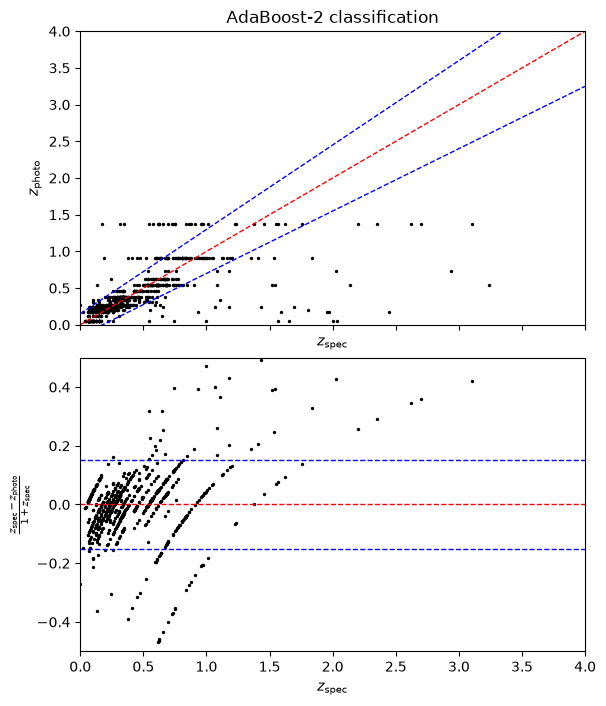

In [12]:
# Load data
file_path = "/home/sk/Projects/Astrophysics/data/ATLAS.csv"
X_train, X_test, y_train, y_test = training_set_2(file_path)

# Combine redshifts and create 15 bins
y_all = np.concatenate([y_train, y_test])
y_all_binned, bin_edges, bin_values = binDataFunc(y_all.copy(), 15)

# Separate binned redshifts
n_train = len(y_train)
y_train_binned = y_all_binned[:n_train]
y_test_binned = y_all_binned[n_train:]

print("Training sources:", len(X_train))
print("Testing sources:", len(X_test))

# Convert binned redshifts to integer class labels
y_train_class = np.searchsorted(bin_values, y_train_binned).astype(int)
y_test_class = np.searchsorted(bin_values, y_test_binned).astype(int)

print("Number of classes:", len(bin_values))
print("Training classes:", np.unique(y_train_class))
print("Testing classes:", np.unique(y_test_class))

# AdaBoost + GridSearchCV
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42)

param_grid = {
    "n_estimators": [50, 100, 500, 1000, 1500],
    "learning_rate": [0.001, 0.01, 0.1, 1.0],
    "estimator__max_depth": [1, 2, 3]
}

grid_search = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search.fit(X_train, y_train_class)

# Best model
best_model = grid_search.best_estimator_
print("\nGridSearchCV Results")
print("Best CV accuracy:", grid_search.best_score_)
print("Best parameters:", grid_search.best_params_)

# Predict CDFS using the best model
predicted_class = best_model.predict(X_test)
bin_values = np.asarray(bin_values)
final_prediction = bin_values[predicted_class]

# Classification accuracy on CDFS
accuracy = np.mean(predicted_class == y_test_class)

# Photometric-redshift metrics
y_true = np.asarray(y_test, dtype=np.float32)
y_pred = np.asarray(final_prediction, dtype=np.float32)
residuals = (y_true - y_pred) / (1 + y_true)

# eta_0.15
eta_015_value = np.mean(np.abs(residuals) > 0.15)

# sigma
sigma = np.std(residuals)

# eta_2sigma
eta_2sigma = np.mean(np.abs(residuals) > 2 * sigma)

# sigma_NMAD
delta_z = (y_true - y_pred) / (1 + y_true)
sigma_nmad = 1.48 * np.median(np.abs(delta_z - np.median(delta_z)))

# MAE
mae = np.mean(np.abs(y_true - y_pred))

# RMSE
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

# R²
r2 = r2_score(y_true, y_pred)

# Final results
print("AdaBoost-1 Final Results")
print("Training : ELAIS-S1")
print("Testing  : CDFS")
print("\nBest AdaBoost parameters:")
print("Number of estimators:", best_model.n_estimators)
print("Learning rate:", best_model.learning_rate)
print("Tree depth:", best_model.estimator.max_depth)
print("\n10-fold CV accuracy:", grid_search.best_score_)
print("\nPhotometric-redshift metrics:")
print("eta_0.15  :", eta_015_value * 100, "%")
print("eta_2sigma:", eta_2sigma * 100, "%")
print("Test classification accuracy:", accuracy)
print("sigma     :", sigma)

print("sigma_NMAD:", sigma_nmad)
print("MAE       :", mae)
print("RMSE      :", rmse)
print("R²        :", r2)

# plot classification scatter graph
plot_classification_scatter(y_test, y_pred, title="AdaBoost-2 classification")

# AdaBoost 3

Training sources: 816
Testing sources: 495
Number of classes: 15
Training classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Testing classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Fitting 10 folds for each of 60 candidates, totalling 600 fits

GridSearchCV Results
Best CV accuracy: 0.32589581451370064
Best parameters: {'estimator__max_depth': 3, 'learning_rate': 1.0, 'n_estimators': 1500}
AdaBoost-3 Final Results
Training : CDFS
Testing  : ELAIS-S1

Best AdaBoost parameters:
Number of estimators: 1500
Learning rate: 1.0
Tree depth: 3

10-fold CV accuracy: 0.32589581451370064

Photometric-redshift metrics:
eta_0.15  : 13.535353535353536 %
eta_2sigma: 6.4646464646464645 %
Test classification accuracy: 0.31717171717171716
sigma     : 0.12168381
sigma_NMAD: 0.066168435
MAE       : 0.13662751
RMSE      : 0.30556068
R²        : 0.5022209882736206


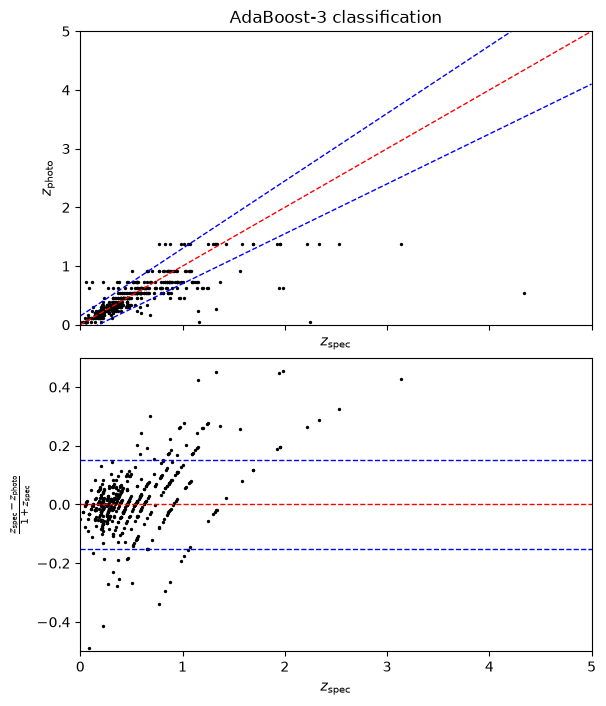

In [13]:
# Load data
file_path = "/home/sk/Projects/Astrophysics/data/ATLAS.csv"
X_train, X_test, y_train, y_test = training_set_3(file_path)

# Combine redshifts and create 15 bins
y_all = np.concatenate([y_train, y_test])
y_all_binned, bin_edges, bin_values = binDataFunc(y_all.copy(), 15)

# Separate binned redshifts
n_train = len(y_train)
y_train_binned = y_all_binned[:n_train]
y_test_binned = y_all_binned[n_train:]

print("Training sources:", len(X_train))
print("Testing sources:", len(X_test))

# Convert binned redshifts to integer class labels
y_train_class = np.searchsorted(bin_values, y_train_binned).astype(int)
y_test_class = np.searchsorted(bin_values, y_test_binned).astype(int)

print("Number of classes:", len(bin_values))
print("Training classes:", np.unique(y_train_class))
print("Testing classes:", np.unique(y_test_class))

# AdaBoost + GridSearchCV
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42)

param_grid = {
    "n_estimators": [50, 100, 500, 1000, 1500],
    "learning_rate": [0.001, 0.01, 0.1, 1.0],
    "estimator__max_depth": [1, 2, 3]
}

grid_search = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search.fit(X_train, y_train_class)

# Best model
best_model = grid_search.best_estimator_
print("\nGridSearchCV Results")
print("Best CV accuracy:", grid_search.best_score_)
print("Best parameters:", grid_search.best_params_)

# Predict CDFS using the best model
predicted_class = best_model.predict(X_test)
bin_values = np.asarray(bin_values)
final_prediction = bin_values[predicted_class]

# Classification accuracy on CDFS
accuracy = np.mean(predicted_class == y_test_class)

# Photometric-redshift metrics
y_true = np.asarray(y_test, dtype=np.float32)
y_pred = np.asarray(final_prediction, dtype=np.float32)
residuals = (y_true - y_pred) / (1 + y_true)

# eta_0.15
eta_015_value = np.mean(np.abs(residuals) > 0.15)

# sigma
sigma = np.std(residuals)

# eta_2sigma
eta_2sigma = np.mean(np.abs(residuals) > 2 * sigma)

# sigma_NMAD
delta_z = (y_true - y_pred) / (1 + y_true)
sigma_nmad = 1.48 * np.median(np.abs(delta_z - np.median(delta_z)))

# MAE
mae = np.mean(np.abs(y_true - y_pred))

# RMSE
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

# R²
r2 = r2_score(y_true, y_pred)

# Final results
print("AdaBoost-3 Final Results")
print("Training : CDFS")
print("Testing  : ELAIS-S1")
print("\nBest AdaBoost parameters:")
print("Number of estimators:", best_model.n_estimators)
print("Learning rate:", best_model.learning_rate)
print("Tree depth:", best_model.estimator.max_depth)
print("\n10-fold CV accuracy:", grid_search.best_score_)
print("\nPhotometric-redshift metrics:")
print("eta_0.15  :", eta_015_value * 100, "%")
print("eta_2sigma:", eta_2sigma * 100, "%")
print("Test classification accuracy:", accuracy)
print("sigma     :", sigma)

print("sigma_NMAD:", sigma_nmad)
print("MAE       :", mae)
print("RMSE      :", rmse)
print("R²        :", r2)

# plot classification scatter graph
plot_classification_scatter(y_test, y_pred, title="AdaBoost-3 classification")

# Verify the binned Z with the original Z

In [211]:
# Check one random training sample
idx = np.random.randint(len(y_train))

print("Random index       :", idx)
print("Original z         :", y_train[idx])
print("Binned z           :", y_train_binned[idx])
print("Assigned class     :", y_train_class[idx])
print("bin_values[class]  :", bin_values[y_train_class[idx]])

print(
    "Correct labeling?  :",
    y_train_binned[idx] == bin_values[y_train_class[idx]]
)

Random index       : 2
Original z         : 0.2074
Binned z           : 0.20536786
Assigned class     : 3
bin_values[class]  : 0.20536786
Correct labeling?  : True
